# V4a — Logistic Preference Model

В этом ноутбуке проверяется первый шаг V4: **может ли Preference Model учиться по истории A/B-выборов пользователя**.

Важно: на этом этапе Pair Generator фиксирован (`Semantic active v3`). Модель **ещё не управляет генерацией пар**. Она только наблюдает пары `A/B`, выбор synthetic user и обновляет внутреннюю оценку предпочтений.

Сравниваются две траектории:

- `Heuristic state` — текущий baseline update, который двигает `z_mean` в сторону выбранного варианта;
- `Logistic Preference Model` — онлайн-модель, которая учит собственный `z_pref` по pairwise logistic loss.

Метрики:

- расстояние до скрытого `z_target`;
- log loss предсказания выбора;
- accuracy предсказания выбора;
- cosine similarity между `z_pref` и скрытым target.


In [6]:
from personalization.plotting import use_article_style
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from personalization.synthetic_dataset import load_synthetic_users_dataset
from personalization.preference_model_eval import (
    run_preference_model_batch_v4a,
    summarize_v4a_by_target_mode,
    save_v4a_outputs,
)

use_article_style()

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.grid': True,
    'grid.alpha': 0.25,
    'grid.linestyle': '--',
    'font.size': 12,
    'axes.titlesize': 18,
    'axes.titleweight': 'bold',
    'axes.labelsize': 14,
    'legend.fontsize': 12,
})

DATASET_PATH = ROOT / 'outputs/datasets/synthetic_users_v21.csv'
OUTPUT_METRICS_DIR = ROOT / 'outputs/metrics'
OUTPUT_FIGURES_DIR = ROOT / 'outputs/figures'
OUTPUT_METRICS_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

DATASET_PATH


WindowsPath('C:/Users/makcc/PycharmProjects/EarLoop/research/eq_personalization/outputs/datasets/synthetic_users_v21.csv')

## 1. Загрузка fixed synthetic user dataset

In [2]:
dataset = load_synthetic_users_dataset(DATASET_PATH)
print(dataset.shape)
dataset['target_mode'].value_counts()


(400, 48)


target_mode
random8d       100
semantic4d     100
semantic6d     100
archetype8d    100
Name: count, dtype: int64

## 2. Запуск V4a

Pair Generator фиксируем как `semantic_active_v21`, чтобы отдельно проверить обучение Preference Model.

Параметры модели:

- `model_lr=0.18`;
- `temperature=0.75`;
- `l2=0.003`;
- feature weights внутри модели uniform, то есть модель **не знает synthetic feature_importance**.


In [3]:
sessions_v4a, steps_v4a, curves_v4a = run_preference_model_batch_v4a(
    dataset=dataset,
    n_steps=25,
    pair_strategy='semantic_active_v21',
    step_scale=0.6,
    heuristic_lr=0.25,
    model_lr=0.18,
    model_temperature=0.75,
    model_l2=0.003,
    model_feature_weight='uniform',
)

summary_v4a = summarize_v4a_by_target_mode(sessions_v4a)

save_v4a_outputs(
    sessions_v4a,
    steps_v4a,
    summary_v4a,
    output_dir=OUTPUT_METRICS_DIR,
    prefix='notebook_v4a_logistic_preference_model',
)

summary_v4a


,target_mode,users,mean_initial_distance,heuristic_mean_final_distance,model_mean_final_distance,heuristic_mean_best_distance,model_mean_best_distance,heuristic_mean_improvement_pct,model_mean_improvement_pct,mean_prediction_accuracy,mean_log_loss_before,mean_log_loss_after,mean_final_model_cosine_to_target
0,archetype8d,100,1.102635,0.371572,0.367522,0.277011,0.276671,58.080527,58.618380,0.5620,0.692357,0.414284,0.894636
1,random8d,100,2.212002,1.512784,1.513141,1.473502,1.475837,31.176377,31.183174,0.4228,0.695087,0.415567,0.693028
2,semantic4d,100,1.731930,0.414821,0.412109,0.317448,0.317788,73.699711,73.971169,0.4036,0.695633,0.415831,0.967573
3,semantic6d,100,2.251218,0.554277,0.557315,0.501446,0.507154,75.051197,75.040653,0.3452,0.698038,0.416979,0.970177


## 3. Сводная таблица по target mode

In [4]:
display_cols = [
    'target_mode',
    'users',
    'mean_initial_distance',
    'heuristic_mean_final_distance',
    'model_mean_final_distance',
    'heuristic_mean_best_distance',
    'model_mean_best_distance',
    'heuristic_mean_improvement_pct',
    'model_mean_improvement_pct',
    'mean_prediction_accuracy',
    'mean_log_loss_before',
    'mean_log_loss_after',
    'mean_final_model_cosine_to_target',
]

summary_v4a[display_cols].round(3)


,target_mode,users,mean_initial_distance,heuristic_mean_final_distance,model_mean_final_distance,heuristic_mean_best_distance,model_mean_best_distance,heuristic_mean_improvement_pct,model_mean_improvement_pct,mean_prediction_accuracy,mean_log_loss_before,mean_log_loss_after,mean_final_model_cosine_to_target
0,archetype8d,100,1.103,0.372,0.368,0.277,0.277,58.081,58.618,0.562,0.692,0.414,0.895
1,random8d,100,2.212,1.513,1.513,1.474,1.476,31.176,31.183,0.423,0.695,0.416,0.693
2,semantic4d,100,1.732,0.415,0.412,0.317,0.318,73.700,73.971,0.404,0.696,0.416,0.968
3,semantic6d,100,2.251,0.554,0.557,0.501,0.507,75.051,75.041,0.345,0.698,0.417,0.970


## 4. Графики

saved: C:\Users\makcc\PycharmProjects\EarLoop\research\eq_personalization\outputs\figures\v4a_mean_final_distance_by_target_mode.png


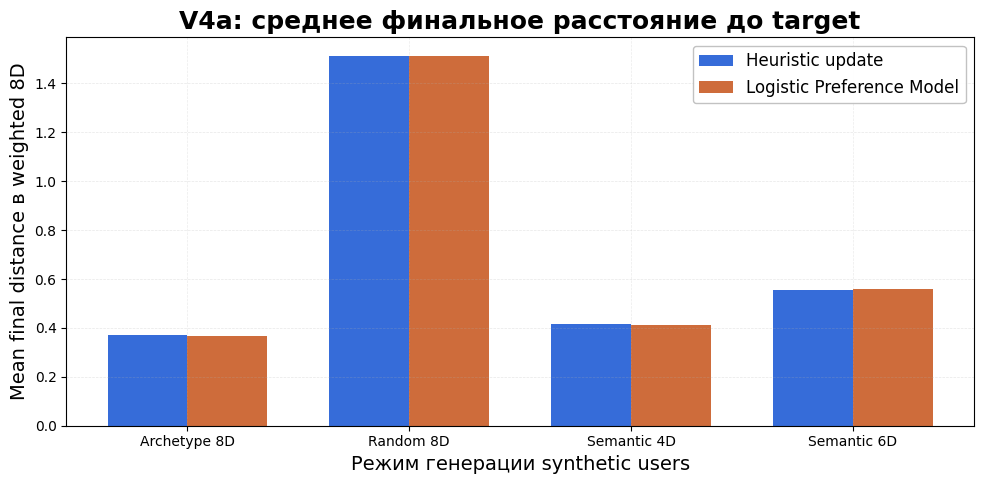

In [7]:
TARGET_MODE_LABELS = {
    'random8d': 'Random 8D',
    'semantic4d': 'Semantic 4D',
    'semantic6d': 'Semantic 6D',
    'archetype8d': 'Archetype 8D',
}

def savefig(name):
    path = OUTPUT_FIGURES_DIR / name
    plt.savefig(path, dpi=220, bbox_inches='tight')
    print('saved:', path)

def plot_mean_final_distance(summary):
    df = summary.copy()
    df['target_label'] = df['target_mode'].map(TARGET_MODE_LABELS).fillna(df['target_mode'])
    x = np.arange(len(df))
    width = 0.36

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(x - width/2, df['heuristic_mean_final_distance'], width, label='Heuristic update')
    ax.bar(x + width/2, df['model_mean_final_distance'], width, label='Logistic Preference Model')

    ax.set_title('V4a: среднее финальное расстояние до target')
    ax.set_xlabel('Режим генерации synthetic users')
    ax.set_ylabel('Mean final distance в weighted 8D')
    ax.set_xticks(x)
    ax.set_xticklabels(df['target_label'])
    ax.legend(frameon=True, facecolor='white', edgecolor='0.75')
    ax.grid(True, axis='y', alpha=0.3, linestyle='--')
    plt.tight_layout()
    savefig('v4a_mean_final_distance_by_target_mode.png')
    plt.show()

plot_mean_final_distance(summary_v4a)


saved: C:\Users\makcc\PycharmProjects\EarLoop\research\eq_personalization\outputs\figures\v4a_distance_curves_archetype8d.png


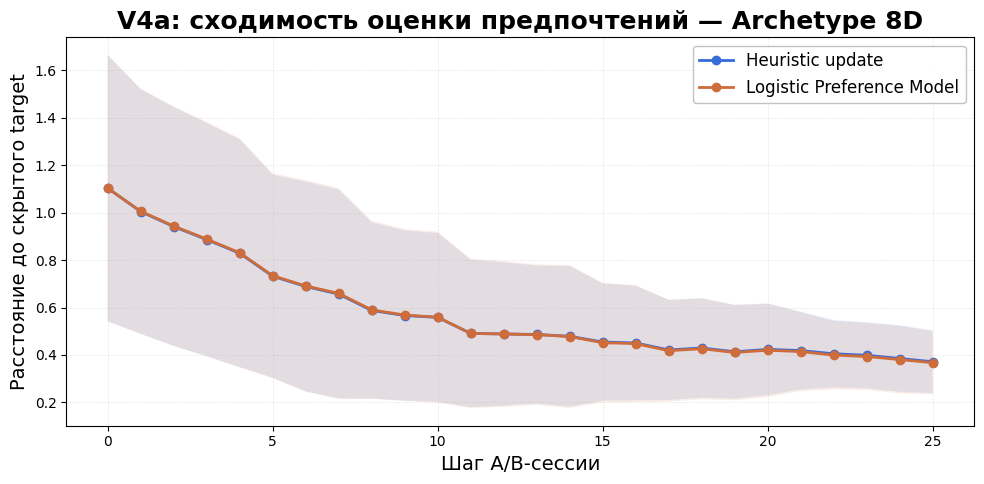

saved: C:\Users\makcc\PycharmProjects\EarLoop\research\eq_personalization\outputs\figures\v4a_distance_curves_semantic6d.png


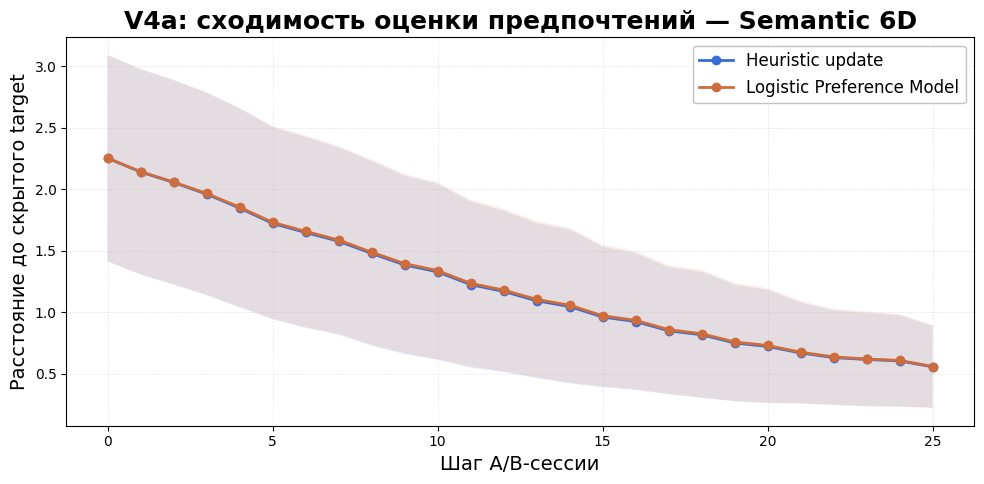

In [8]:
def plot_distance_curves(curves, target_mode='archetype8d'):
    labels = {
        'heuristic': 'Heuristic update',
        'model': 'Logistic Preference Model',
    }
    title_label = TARGET_MODE_LABELS.get(target_mode, target_mode)

    fig, ax = plt.subplots(figsize=(10, 5))
    steps = None

    for key in ['heuristic', 'model']:
        arr = curves[target_mode][key]
        mean = arr.mean(axis=0)
        std = arr.std(axis=0)
        steps = np.arange(len(mean))
        ax.plot(steps, mean, marker='o', linewidth=2, label=labels[key])
        ax.fill_between(steps, mean - std, mean + std, alpha=0.12)

    ax.set_title(f'V4a: сходимость оценки предпочтений — {title_label}')
    ax.set_xlabel('Шаг A/B-сессии')
    ax.set_ylabel('Расстояние до скрытого target')
    ax.legend(frameon=True, facecolor='white', edgecolor='0.75')
    ax.grid(True, alpha=0.3, linestyle='--')
    plt.tight_layout()
    savefig(f'v4a_distance_curves_{target_mode}.png')
    plt.show()

plot_distance_curves(curves_v4a, 'archetype8d')
plot_distance_curves(curves_v4a, 'semantic6d')


saved: C:\Users\makcc\PycharmProjects\EarLoop\research\eq_personalization\outputs\figures\v4a_model_cosine_archetype8d.png


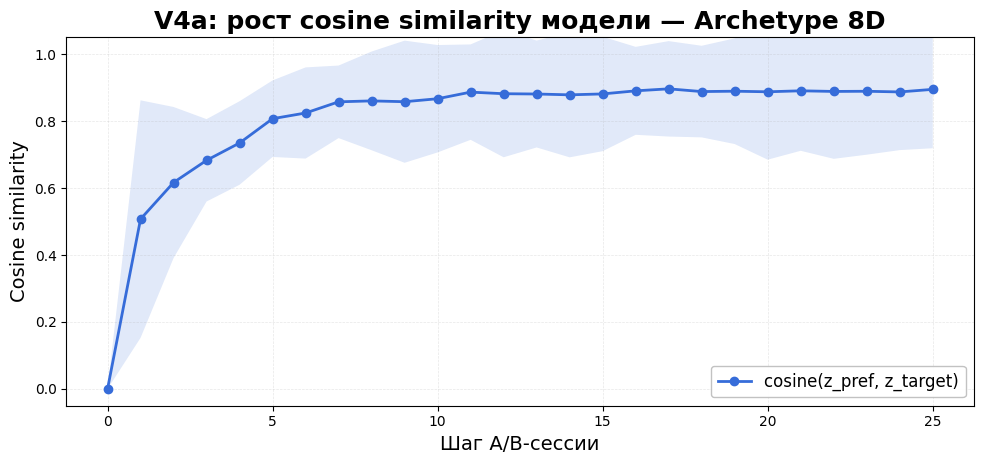

saved: C:\Users\makcc\PycharmProjects\EarLoop\research\eq_personalization\outputs\figures\v4a_model_cosine_semantic6d.png


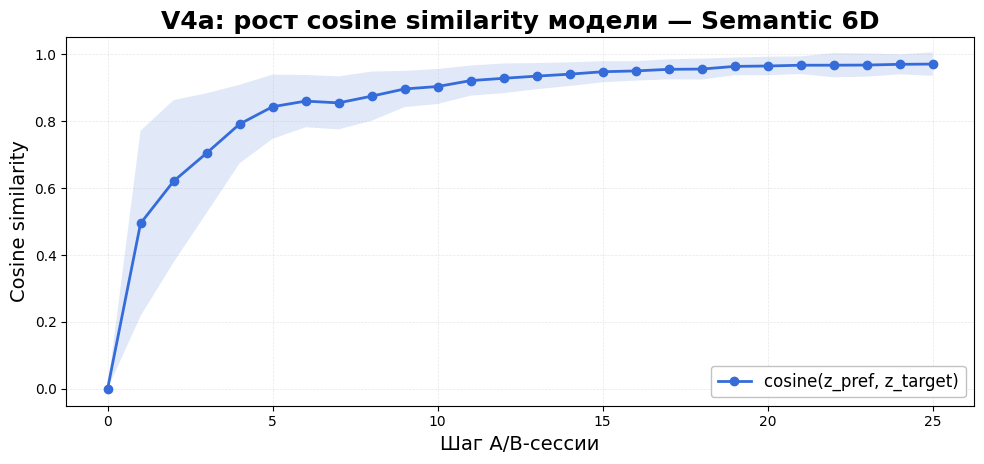

In [9]:
def plot_model_cosine_curves(curves, target_mode='archetype8d'):
    arr = curves[target_mode]['cosine']
    mean = arr.mean(axis=0)
    std = arr.std(axis=0)
    steps = np.arange(len(mean))
    title_label = TARGET_MODE_LABELS.get(target_mode, target_mode)

    fig, ax = plt.subplots(figsize=(10, 4.8))
    ax.plot(steps, mean, marker='o', linewidth=2, label='cosine(z_pref, z_target)')
    ax.fill_between(steps, mean - std, mean + std, alpha=0.15)
    ax.set_title(f'V4a: рост cosine similarity модели — {title_label}')
    ax.set_xlabel('Шаг A/B-сессии')
    ax.set_ylabel('Cosine similarity')
    ax.set_ylim(-0.05, 1.05)
    ax.legend(frameon=True, facecolor='white', edgecolor='0.75')
    ax.grid(True, alpha=0.3, linestyle='--')
    plt.tight_layout()
    savefig(f'v4a_model_cosine_{target_mode}.png')
    plt.show()

plot_model_cosine_curves(curves_v4a, 'archetype8d')
plot_model_cosine_curves(curves_v4a, 'semantic6d')


saved: C:\Users\makcc\PycharmProjects\EarLoop\research\eq_personalization\outputs\figures\v4a_log_loss_archetype8d.png


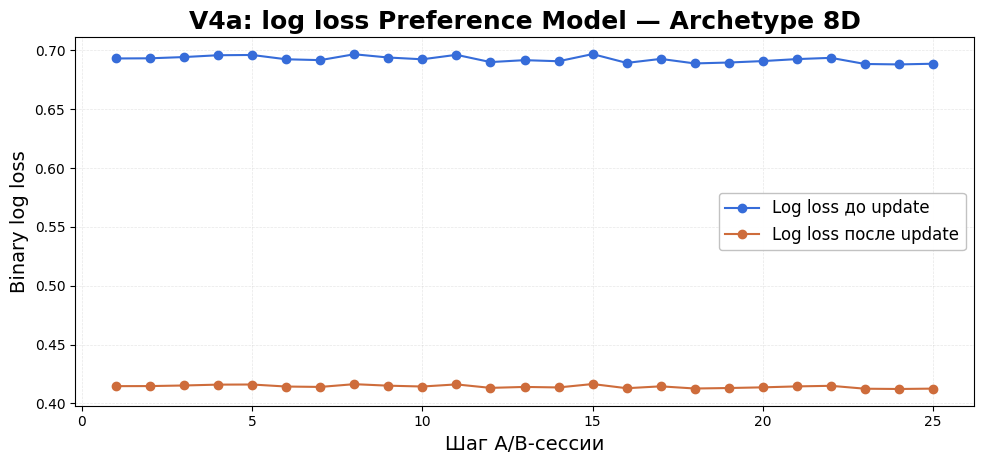

saved: C:\Users\makcc\PycharmProjects\EarLoop\research\eq_personalization\outputs\figures\v4a_log_loss_semantic6d.png


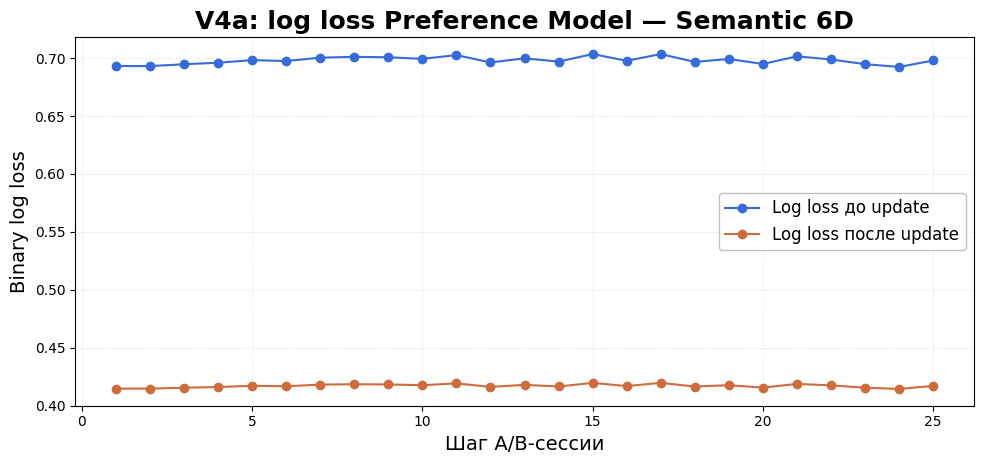

In [10]:
def plot_log_loss_by_step(steps_df, target_mode='archetype8d'):
    df = steps_df[steps_df['target_mode'] == target_mode].copy()
    grouped = (
        df.groupby('step')
        .agg(
            log_loss_before=('log_loss_before', 'mean'),
            log_loss_after=('log_loss_after', 'mean'),
            accuracy=('correct_before', 'mean'),
        )
        .reset_index()
    )
    title_label = TARGET_MODE_LABELS.get(target_mode, target_mode)

    fig, ax = plt.subplots(figsize=(10, 4.8))
    ax.plot(grouped['step'], grouped['log_loss_before'], marker='o', label='Log loss до update')
    ax.plot(grouped['step'], grouped['log_loss_after'], marker='o', label='Log loss после update')
    ax.set_title(f'V4a: log loss Preference Model — {title_label}')
    ax.set_xlabel('Шаг A/B-сессии')
    ax.set_ylabel('Binary log loss')
    ax.legend(frameon=True, facecolor='white', edgecolor='0.75')
    ax.grid(True, alpha=0.3, linestyle='--')
    plt.tight_layout()
    savefig(f'v4a_log_loss_{target_mode}.png')
    plt.show()

plot_log_loss_by_step(steps_v4a, 'archetype8d')
plot_log_loss_by_step(steps_v4a, 'semantic6d')


saved: C:\Users\makcc\PycharmProjects\EarLoop\research\eq_personalization\outputs\figures\v4a_prediction_accuracy_by_target_mode.png


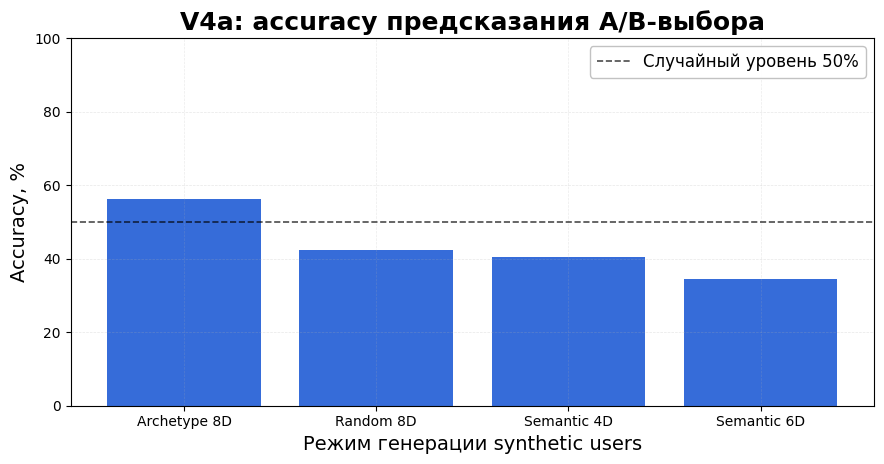

In [11]:
def plot_prediction_accuracy(summary):
    df = summary.copy()
    df['target_label'] = df['target_mode'].map(TARGET_MODE_LABELS).fillna(df['target_mode'])

    fig, ax = plt.subplots(figsize=(9, 4.8))
    ax.bar(df['target_label'], 100.0 * df['mean_prediction_accuracy'])
    ax.axhline(50.0, color='black', linestyle='--', linewidth=1.2, alpha=0.7, label='Случайный уровень 50%')
    ax.set_title('V4a: accuracy предсказания A/B-выбора')
    ax.set_xlabel('Режим генерации synthetic users')
    ax.set_ylabel('Accuracy, %')
    ax.set_ylim(0, 100)
    ax.legend(frameon=True, facecolor='white', edgecolor='0.75')
    ax.grid(True, axis='y', alpha=0.3, linestyle='--')
    plt.tight_layout()
    savefig('v4a_prediction_accuracy_by_target_mode.png')
    plt.show()

plot_prediction_accuracy(summary_v4a)


## 5. Интерпретация

В этом эксперименте `Logistic Preference Model` не управляет Pair Generator. Она получает те же A/B-ответы, что и baseline-контур, и учится онлайн.

Что важно смотреть:

1. **distance curve** — становится ли `z_pref` модели ближе к скрытому `z_target`;
2. **cosine similarity** — совпадает ли направление оценки модели с направлением настоящего target;
3. **log loss** — улучшается ли предсказание текущих A/B-наблюдений после update;
4. **final_distance** — может ли модель конкурировать с эвристическим `z_mean` как оценка preference state.


In [12]:
# Готовая короткая текстовая сводка для вывода
arch = summary_v4a[summary_v4a['target_mode'] == 'archetype8d'].iloc[0]
sem6 = summary_v4a[summary_v4a['target_mode'] == 'semantic6d'].iloc[0]

print('Archetype 8D:')
print(f"  Heuristic final distance: {arch['heuristic_mean_final_distance']:.3f}")
print(f"  Model final distance:     {arch['model_mean_final_distance']:.3f}")
print(f"  Model cosine to target:   {arch['mean_final_model_cosine_to_target']:.3f}")
print(f"  Prediction accuracy:      {100*arch['mean_prediction_accuracy']:.1f}%")
print()
print('Semantic 6D:')
print(f"  Heuristic final distance: {sem6['heuristic_mean_final_distance']:.3f}")
print(f"  Model final distance:     {sem6['model_mean_final_distance']:.3f}")
print(f"  Model cosine to target:   {sem6['mean_final_model_cosine_to_target']:.3f}")
print(f"  Prediction accuracy:      {100*sem6['mean_prediction_accuracy']:.1f}%")


Archetype 8D:
  Heuristic final distance: 0.372
  Model final distance:     0.368
  Model cosine to target:   0.895
  Prediction accuracy:      56.2%

Semantic 6D:
  Heuristic final distance: 0.554
  Model final distance:     0.557
  Model cosine to target:   0.970
  Prediction accuracy:      34.5%


V4a показал, что Logistic Preference Model способна извлекать направление скрытого preference target из истории A/B-ответов. Это подтверждается высокой cosine similarity между вектором модели и target-вектором synthetic user. Однако текущая линейная модель пока не даёт устойчивого улучшения final distance относительно эвристического update, поэтому её нельзя считать полноценной заменой текущего preference update.